In [8]:
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt
import sys,os
sys.path.append(os.path.abspath('../'))
from psyduck.operations import parity_operator
from psyduck.evolve import free_decay
from psyduck.noise import get_collapse_operators
from psyduck import Spin

# Cat free decay phase dependence

I observed a small dependence of the cat phase on the dephasing time of the cat states. 

In [9]:
parity_op = parity_operator(I=7/2)
parity_op

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 1.  0.  0.  0.  0.  0.  0.  0.]
 [ 0. -1.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  1.  0.  0.  0.  0.  0.]
 [ 0.  0.  0. -1.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  1.  0.  0.  0.]
 [ 0.  0.  0.  0.  0. -1.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  1.  0.]
 [ 0.  0.  0.  0.  0.  0.  0. -1.]]

In [10]:
# noise model parameters
exponent_e = 1.2
exponent_m = 1.60449971294319
T2_star_m = 200e-3
T2_star_e = 300e-3
c_ops = get_collapse_operators(I=7/2, T2_star_m=T2_star_m, exponent_m=exponent_m, T2_star_e=T2_star_e, exponent_e=exponent_e)

In [11]:
nucleus = Spin(I=7/2)
nucleus.make_xcat_state(phi=0)
nucleus.parity()

-0.9999999999999998

In [20]:
ny = np.array([0, 1, 0])
nx = np.array([1, 0, 0])
thetas = np.linspace(0, np.pi * 2, 50)
times = np.linspace(0, 200e-3, 100)
fidelity = np.zeros([len(thetas), 3, len(times)], dtype=float)
T2s = np.zeros([len(thetas), 3])
alphas = np.zeros([len(thetas), 3])
parity = np.zeros([len(thetas), 3])
spin_sizes = [3/2, 5/2, 7/2]
nuclei = [Spin(I=spin_size) for spin_size in spin_sizes]

for t, theta in enumerate(thetas):
    for p, spin_size in enumerate(spin_sizes):
        nuclei[p].make_xcat_state(phi=theta)
        cops = get_collapse_operators(I=spin_size, T2_star_m=T2_star_m, exponent_m=exponent_m, T2_star_e=T2_star_e, exponent_e=exponent_e)
        fidelity[t, p], T2s[t, p], alphas[t, p] = free_decay([nuclei[p].state], times, cops)
    for p, nucleus in enumerate(nuclei):
        parity[t, p] = nucleus.parity()

C:\Users\z5380600\AppData\Local\Temp\ipykernel_104484\1444037014.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  fidelity[t, p], T2s[t, p], alphas[t, p] = free_decay([nuclei[p].state], times, cops)


Text(0.5, 0, '$\\varphi$ ($\\pi$)')

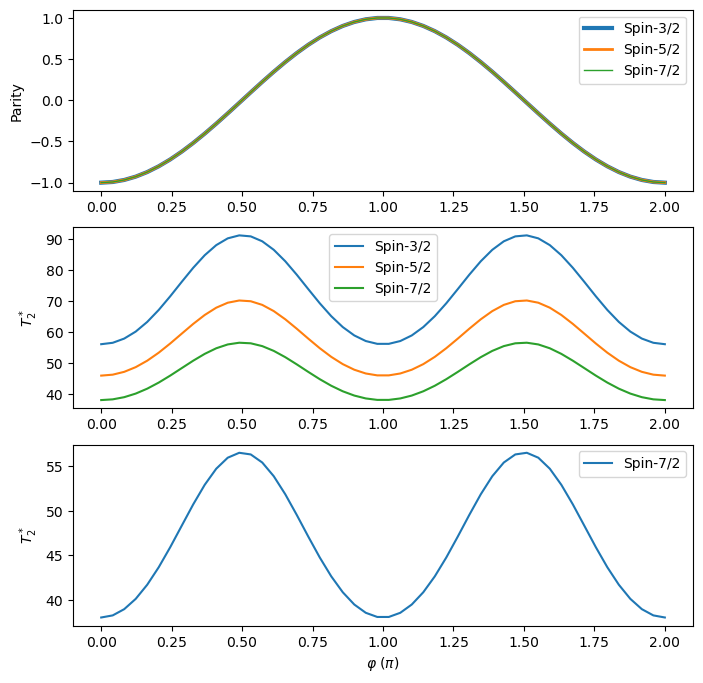

In [21]:
fig, ax = plt.subplots(3,1, figsize=(8, 8), dpi=100)

labels = ['Spin-3/2', 'Spin-5/2', 'Spin-7/2']

for i in range(len(psi0s)):
    ax[0].plot(thetas/np.pi, parity[:, i], label=labels[i], lw=3-i)

for i in range(len(psi0s)):
    ax[1].plot(thetas/np.pi, T2s[:, i]*1e3, label=labels[i])

ax[0].legend()
ax[1].legend()

ax[2].plot(thetas/np.pi, T2s[:, 2]*1e3, label='Spin-7/2')
ax[2].legend()

ax[0].set_ylabel('Parity')
ax[1].set_ylabel(r'$T_2^*$')
ax[2].set_ylabel(r'$T_2^*$')

ax[2].set_xlabel(r'$\varphi$ ($\pi$)')